In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [5]:
# Does an order marked with higher Order Priority actually correlate with higher shipping costs or faster delivery times?

In [6]:
df['Order Priority'].drop_duplicates()

0       Medium
4         High
16    Critical
70     Unknown
89         Low
Name: Order Priority, dtype: str

In [7]:
prio_order_time = df[['Order Priority','Order Date','Ship Date','Shipping Cost']]
prio_order_time

,Order Priority,Order Date,Ship Date,Shipping Cost
0,Medium,2012-12-24,2013-01-09,0.79
1,Medium,2011-07-21,2011-08-07,0.97
2,Medium,2014-09-18,2014-09-28,3.71
3,Medium,2013-04-10,2013-10-26,0.06
4,High,2014-10-29,2014-11-27,0.00
...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76
51366,High,2011-11-03,2011-08-07,64.42
51367,Medium,2011-12-23,2012-01-11,5.84
51368,Medium,2013-08-07,2013-11-19,2.96


In [8]:
prio_order_time.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order Priority  51370 non-null  str    
 1   Order Date      51370 non-null  str    
 2   Ship Date       51370 non-null  str    
 3   Shipping Cost   51370 non-null  float64
dtypes: float64(1), str(3)
memory usage: 1.6 MB


In [9]:
prio_order_time['Order Date'] = pd.to_datetime(prio_order_time['Order Date'])
prio_order_time['Ship Date'] = pd.to_datetime(prio_order_time['Ship Date'])


In [10]:
prio_order_time['processing_time'] = prio_order_time['Ship Date'] - prio_order_time['Order Date']

In [11]:
prio_order_time

,Order Priority,Order Date,Ship Date,Shipping Cost,processing_time
0,Medium,2012-12-24,2013-01-09,0.79,16 days
1,Medium,2011-07-21,2011-08-07,0.97,17 days
2,Medium,2014-09-18,2014-09-28,3.71,10 days
3,Medium,2013-04-10,2013-10-26,0.06,199 days
4,High,2014-10-29,2014-11-27,0.00,29 days
...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,-75 days
51366,High,2011-11-03,2011-08-07,64.42,-88 days
51367,Medium,2011-12-23,2012-01-11,5.84,19 days
51368,Medium,2013-08-07,2013-11-19,2.96,104 days


In [12]:
prio_order_time['processing_time'] = prio_order_time['processing_time'].astype(str)

In [13]:
prio_order_time['processing_time'] = prio_order_time['processing_time'].str.replace(r'[-|days| ]','', regex=True)

In [14]:
prio_order_time['processing_time'] = prio_order_time['processing_time'].str.strip()

In [15]:
prio_order_time

,Order Priority,Order Date,Ship Date,Shipping Cost,processing_time
0,Medium,2012-12-24,2013-01-09,0.79,16
1,Medium,2011-07-21,2011-08-07,0.97,17
2,Medium,2014-09-18,2014-09-28,3.71,10
3,Medium,2013-04-10,2013-10-26,0.06,199
4,High,2014-10-29,2014-11-27,0.00,29
...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75
51366,High,2011-11-03,2011-08-07,64.42,88
51367,Medium,2011-12-23,2012-01-11,5.84,19
51368,Medium,2013-08-07,2013-11-19,2.96,104


In [16]:
prio_order_time['processing_time'] = prio_order_time['processing_time'].astype(int)

In [17]:
orderprio_shippingcost_deliverytime = prio_order_time.groupby(prio_order_time['Order Priority'])[['Shipping Cost','processing_time']].mean().round(2)
orderprio_shippingcost_deliverytime.reset_index(inplace=True)

In [18]:
orderprio_shippingcost_deliverytime

,Order Priority,Shipping Cost,processing_time
0,Critical,58.86,195.62
1,High,32.21,224.92
2,Low,26.76,306.28
3,Medium,18.05,256.96
4,Unknown,23.82,241.18


In [19]:
orderprio_shippingcost_deliverytime.rename(columns={'Order Priority':'order_priority','Shipping Cost':'shipping_cost'}, inplace=True)

In [20]:
# Does an order marked with higher Order Priority actually correlate with higher shipping costs or faster delivery times?

In [21]:
prio_order_time.rename(columns={
    'Order Priority':'order_priority',
    'Order Date':'order_date',
    'Ship Date':'ship_date',
    'Shipping Cost':'shipping_cost',
}, inplace=True)
prio_order_time

,order_priority,order_date,ship_date,shipping_cost,processing_time
0,Medium,2012-12-24,2013-01-09,0.79,16
1,Medium,2011-07-21,2011-08-07,0.97,17
2,Medium,2014-09-18,2014-09-28,3.71,10
3,Medium,2013-04-10,2013-10-26,0.06,199
4,High,2014-10-29,2014-11-27,0.00,29
...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75
51366,High,2011-11-03,2011-08-07,64.42,88
51367,Medium,2011-12-23,2012-01-11,5.84,19
51368,Medium,2013-08-07,2013-11-19,2.96,104


In [22]:
prio_order_time['number_of_data_points']=prio_order_time['order_date'].count()

In [23]:
prio_order_time

,order_priority,order_date,ship_date,shipping_cost,processing_time,number_of_data_points
0,Medium,2012-12-24,2013-01-09,0.79,16,51370
1,Medium,2011-07-21,2011-08-07,0.97,17,51370
2,Medium,2014-09-18,2014-09-28,3.71,10,51370
3,Medium,2013-04-10,2013-10-26,0.06,199,51370
4,High,2014-10-29,2014-11-27,0.00,29,51370
...,...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75,51370
51366,High,2011-11-03,2011-08-07,64.42,88,51370
51367,Medium,2011-12-23,2012-01-11,5.84,19,51370
51368,Medium,2013-08-07,2013-11-19,2.96,104,51370


In [24]:
prio_order_time['sum_of_the_product'] = (prio_order_time['shipping_cost'] * prio_order_time['processing_time']).sum().round(2)
prio_order_time

,order_priority,order_date,ship_date,shipping_cost,processing_time,number_of_data_points,sum_of_the_product
0,Medium,2012-12-24,2013-01-09,0.79,16,51370,320454319.9
1,Medium,2011-07-21,2011-08-07,0.97,17,51370,320454319.9
2,Medium,2014-09-18,2014-09-28,3.71,10,51370,320454319.9
3,Medium,2013-04-10,2013-10-26,0.06,199,51370,320454319.9
4,High,2014-10-29,2014-11-27,0.00,29,51370,320454319.9
...,...,...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75,51370,320454319.9
51366,High,2011-11-03,2011-08-07,64.42,88,51370,320454319.9
51367,Medium,2011-12-23,2012-01-11,5.84,19,51370,320454319.9
51368,Medium,2013-08-07,2013-11-19,2.96,104,51370,320454319.9


In [25]:
prio_order_time['sum_shippingcost'] = prio_order_time['shipping_cost'].sum().round(2)
prio_order_time['sum_procctime'] = prio_order_time['processing_time'].sum().round(2)
prio_order_time

,order_priority,order_date,ship_date,shipping_cost,processing_time,number_of_data_points,sum_of_the_product,sum_shippingcost,sum_procctime
0,Medium,2012-12-24,2013-01-09,0.79,16,51370,320454319.9,1325846.68,12575008
1,Medium,2011-07-21,2011-08-07,0.97,17,51370,320454319.9,1325846.68,12575008
2,Medium,2014-09-18,2014-09-28,3.71,10,51370,320454319.9,1325846.68,12575008
3,Medium,2013-04-10,2013-10-26,0.06,199,51370,320454319.9,1325846.68,12575008
4,High,2014-10-29,2014-11-27,0.00,29,51370,320454319.9,1325846.68,12575008
...,...,...,...,...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75,51370,320454319.9,1325846.68,12575008
51366,High,2011-11-03,2011-08-07,64.42,88,51370,320454319.9,1325846.68,12575008
51367,Medium,2011-12-23,2012-01-11,5.84,19,51370,320454319.9,1325846.68,12575008
51368,Medium,2013-08-07,2013-11-19,2.96,104,51370,320454319.9,1325846.68,12575008


In [26]:
prio_order_time['sq_shippingcost']= pow(prio_order_time['sum_shippingcost'],2).round(2)
prio_order_time['sq_procctime']= pow(prio_order_time['sum_procctime'],2).round(2)

In [27]:
prio_order_time

,order_priority,order_date,ship_date,shipping_cost,processing_time,number_of_data_points,sum_of_the_product,sum_shippingcost,sum_procctime,sq_shippingcost,sq_procctime
0,Medium,2012-12-24,2013-01-09,0.79,16,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064
1,Medium,2011-07-21,2011-08-07,0.97,17,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064
2,Medium,2014-09-18,2014-09-28,3.71,10,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064
3,Medium,2013-04-10,2013-10-26,0.06,199,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064
4,High,2014-10-29,2014-11-27,0.00,29,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064
...,...,...,...,...,...,...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064
51366,High,2011-11-03,2011-08-07,64.42,88,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064
51367,Medium,2011-12-23,2012-01-11,5.84,19,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064
51368,Medium,2013-08-07,2013-11-19,2.96,104,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064


In [28]:
# upper part
upper_part = (prio_order_time['number_of_data_points'] * (prio_order_time['sum_of_the_product'])) - ((prio_order_time['sum_shippingcost']) * (prio_order_time['sum_procctime']))

In [29]:
# lower_left_part
lower_left_part = (prio_order_time['number_of_data_points'] * prio_order_time['sq_shippingcost']) - pow(prio_order_time['sum_shippingcost'],2)

In [30]:
# lower_right_part
lower_right_part = (prio_order_time['number_of_data_points'] * prio_order_time['sq_shippingcost']) - pow(prio_order_time['sum_procctime'],2)

In [31]:
upper_part / np.sqrt(lower_left_part * lower_right_part)

0       -0.000002
1       -0.000002
2       -0.000002
3       -0.000002
4       -0.000002
           ...   
51365   -0.000002
51366   -0.000002
51367   -0.000002
51368   -0.000002
51369   -0.000002
Length: 51370, dtype: float64

In [32]:
prio_order_time['coefficient_score'] = upper_part / np.sqrt(lower_left_part * lower_right_part)

In [33]:
overall_coefficient_score = prio_order_time.groupby(prio_order_time['order_priority'])['coefficient_score'].sum().round(2)
overall_coefficient_score

order_priority
Critical   -0.01
High       -0.04
Low        -0.01
Medium     -0.07
Unknown    -0.00
Name: coefficient_score, dtype: float64

In [34]:
prio_order_time

,order_priority,order_date,ship_date,shipping_cost,processing_time,number_of_data_points,sum_of_the_product,sum_shippingcost,sum_procctime,sq_shippingcost,sq_procctime,coefficient_score
0,Medium,2012-12-24,2013-01-09,0.79,16,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002
1,Medium,2011-07-21,2011-08-07,0.97,17,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002
2,Medium,2014-09-18,2014-09-28,3.71,10,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002
3,Medium,2013-04-10,2013-10-26,0.06,199,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002
4,High,2014-10-29,2014-11-27,0.00,29,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002
51366,High,2011-11-03,2011-08-07,64.42,88,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002
51367,Medium,2011-12-23,2012-01-11,5.84,19,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002
51368,Medium,2013-08-07,2013-11-19,2.96,104,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002


In [35]:
prio_order_time = pd.merge(prio_order_time,overall_coefficient_score, on='order_priority', how='inner')
prio_order_time

,order_priority,order_date,ship_date,shipping_cost,processing_time,number_of_data_points,sum_of_the_product,sum_shippingcost,sum_procctime,sq_shippingcost,sq_procctime,coefficient_score_x,coefficient_score_y
0,Medium,2012-12-24,2013-01-09,0.79,16,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
1,Medium,2011-07-21,2011-08-07,0.97,17,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
2,Medium,2014-09-18,2014-09-28,3.71,10,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
3,Medium,2013-04-10,2013-10-26,0.06,199,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
4,High,2014-10-29,2014-11-27,0.00,29,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
51366,High,2011-11-03,2011-08-07,64.42,88,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.04
51367,Medium,2011-12-23,2012-01-11,5.84,19,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
51368,Medium,2013-08-07,2013-11-19,2.96,104,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07


In [36]:
prio_order_time.rename(columns={
    'coefficient_score_x':'coefficient_score',
    'coefficient_score_y':'agg_coefficient_score'
},inplace=True)
prio_order_time

,order_priority,order_date,ship_date,shipping_cost,processing_time,number_of_data_points,sum_of_the_product,sum_shippingcost,sum_procctime,sq_shippingcost,sq_procctime,coefficient_score,agg_coefficient_score
0,Medium,2012-12-24,2013-01-09,0.79,16,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
1,Medium,2011-07-21,2011-08-07,0.97,17,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
2,Medium,2014-09-18,2014-09-28,3.71,10,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
3,Medium,2013-04-10,2013-10-26,0.06,199,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
4,High,2014-10-29,2014-11-27,0.00,29,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
51366,High,2011-11-03,2011-08-07,64.42,88,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.04
51367,Medium,2011-12-23,2012-01-11,5.84,19,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07
51368,Medium,2013-08-07,2013-11-19,2.96,104,51370,320454319.9,1325846.68,12575008,1.757869e+12,158130826200064,-0.000002,-0.07


In [37]:
prio_order_time['order_priority'] = prio_order_time['order_priority'].replace('Unknown','Other')

In [54]:
prio_order_time[['order_priority','order_date','ship_date','shipping_cost','processing_time']]

,order_priority,order_date,ship_date,shipping_cost,processing_time
0,Medium,2012-12-24,2013-01-09,0.79,16
1,Medium,2011-07-21,2011-08-07,0.97,17
2,Medium,2014-09-18,2014-09-28,3.71,10
3,Medium,2013-04-10,2013-10-26,0.06,199
4,High,2014-10-29,2014-11-27,0.00,29
...,...,...,...,...,...
51365,Medium,2014-08-02,2014-05-19,11.76,75
51366,High,2011-11-03,2011-08-07,64.42,88
51367,Medium,2011-12-23,2012-01-11,5.84,19
51368,Medium,2013-08-07,2013-11-19,2.96,104


In [59]:
avg_ship_proc_orderprio = prio_order_time.groupby(prio_order_time['order_priority'])[['shipping_cost','processing_time']].agg(
    avg_shipping_cost = ('shipping_cost','mean'),
    avg_processing_time = ('processing_time','mean')
).round(2)
avg_ship_proc_orderprio.reset_index(inplace=True)
avg_ship_proc_orderprio

,order_priority,avg_shipping_cost,avg_processing_time
0,Critical,58.86,195.62
1,High,32.21,224.92
2,Low,26.76,306.28
3,Medium,18.05,256.96
4,Other,23.82,241.18


In [60]:
avg_ship_proc_orderprio[['avg_shipping_cost','avg_processing_time']].corr(method='pearson')

,avg_shipping_cost,avg_processing_time
avg_shipping_cost,1.000000,-0.684124
avg_processing_time,-0.684124,1.000000


In [62]:
mask_ordprio_crit = avg_ship_proc_orderprio['order_priority'] == 'Critical'
mask_ordprio_high = avg_ship_proc_orderprio['order_priority'] == 'High'
mask_ordprio_low = avg_ship_proc_orderprio['order_priority'] == 'Low'
mask_ordprio_med = avg_ship_proc_orderprio['order_priority'] == 'Medium'
mask_ordprio_other = avg_ship_proc_orderprio['order_priority'] == 'Other'

In [71]:
avg_ship_proc_orderprio.loc[mask_ordprio_crit,['avg_shipping_cost','avg_processing_time']].corr(method='pearson')

,avg_shipping_cost,avg_processing_time
avg_shipping_cost,NaN,NaN
avg_processing_time,NaN,NaN


In [80]:
prio_order_time = prio_order_time[prio_order_time['processing_time'] < 1000]

In [88]:
prio_order_time_agg = prio_order_time.groupby(prio_order_time['order_priority'])[['shipping_cost','processing_time']].agg(
    avg_shipping_cost = ('shipping_cost','mean'),
    avg_processing_time = ('processing_time','mean')
).round(2)
prio_order_time_agg.reset_index(inplace=True)
prio_order_time_agg

,order_priority,avg_shipping_cost,avg_processing_time
0,Critical,58.94,43.51
1,High,32.11,51.66
2,Low,26.85,59.70
3,Medium,18.08,55.63
4,Other,23.88,53.77


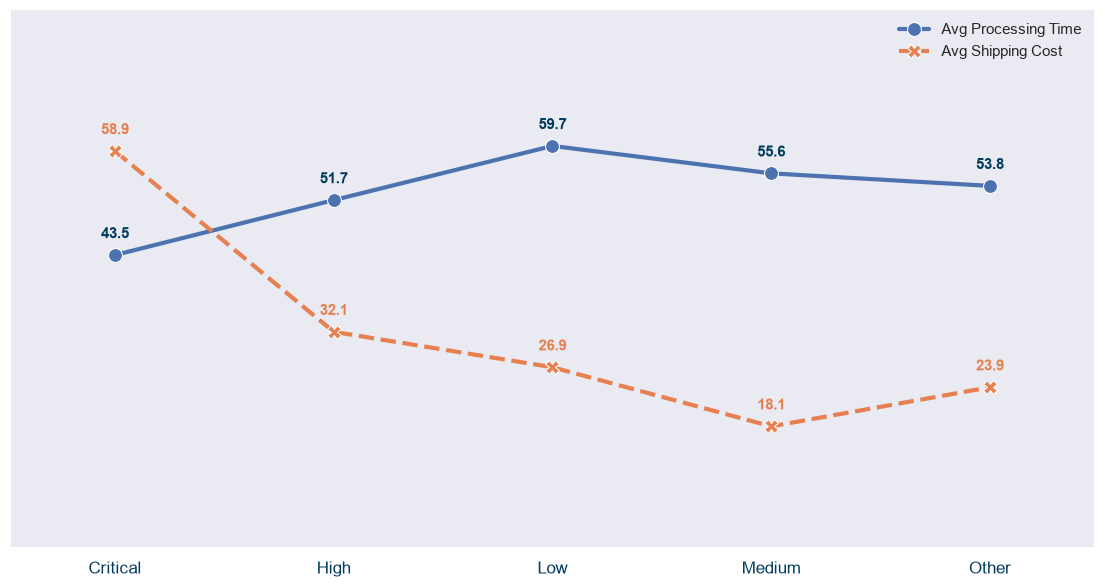

In [176]:
sns.set_theme()
plt.rcParams['axes.grid'] = False
plt.rcParams["axes.xmargin"] = 0.12
plt.rcParams["axes.ymargin"] = 0.12
fig, ax = plt.subplots(figsize=(14,7))

ax = sns.lineplot(
    data=prio_order_time_agg,
    x='order_priority',
    y='avg_processing_time',
    marker='o',
    markersize=10,
    linewidth=3,
    label='Avg Processing Time'
)
ax.set_ylim(0,80)
ax.set_ylabel('')
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_xlabel('')
ax.tick_params(axis='x', labelsize=12, labelcolor='#003B5C')

# ====================== add labels on beside of each marker, ax ======================
for x, y in zip(prio_order_time_agg['order_priority'], prio_order_time_agg['avg_processing_time']):
    ax.annotate(
        f'{y:.1f}',
        xy=(x, y),
        xytext=(0, 15),               # 15 points to the top
        textcoords='offset points',
        ha='center', va='center',
        fontsize=11, color='#003B5C', fontweight='bold'
    )

ax1 = ax.twinx()
ax1 = sns.lineplot(
    data=prio_order_time_agg,
    x='order_priority',
    y='avg_shipping_cost',
    marker='X',
    markersize=10,
    linewidth=3,
    linestyle='--',
    color='#E68050',
    label='Avg Shipping Cost'
)
ax1.set_ylim(0,80)
ax1.set_ylabel('')
ax1.set_yticks([])
ax1.set_yticklabels([])

# ====================== add labels on beside of each marker, ax1 ======================
for x, y in zip(prio_order_time_agg['order_priority'], prio_order_time_agg['avg_shipping_cost']):
    ax1.annotate(
        f'{y:.1f}',
        xy=(x, y),
        xytext=(0, 15),              # 15 points to the top
        textcoords='offset points',
        ha='center', va='center',
        fontsize=11, color='#E68050', fontweight='bold'
    )

# --- combine legends from both axes ---
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax1.get_legend_handles_labels()

ax.legend(handles1 + handles2, labels1 + labels2, loc='upper right', frameon=False)
ax1.legend_.remove() if ax1.get_legend() else None   # remove ax1's own auto-legend if seaborn added one

In [177]:
# Business Question 13:
# Does an order marked with higher Order Priority actually correlate with higher shipping costs or faster delivery times?

# Answer:
# Critical Priority Order shows the closest disparity in shipping and processing of orders, with the discrepancy of 16/17 points while
# Medium Priority Order holds the most distant difference of 37 points. When it comes to High Priority Order, it comes second with 19 points difference
# in shipping and processing.